# NYC Restaurant Inspections Data Analysis
---
## Research Question
How does restaurant health inspection risk vary across neighborhoods in New York City, and what does that variation suggest about the relationship between neighborhood conditions and food safety outcomes?

## Datasets
[New York City Restaurant Inspection Results](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data)

[New York City Rodent Inspections](https://data.cityofnewyork.us/Health/Rodent-Inspection/p937-wjvj/about_data)

[New York City Income Dataset TO BE LOADED]

[New York City 311 Complaint Dataset](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data)

---

## Table of Contents

1.   Setup
2.   Data Loading
3.   Restaurant Inspection Data Analysis (Cleaning, Exploration, Visualization)
4.   Rodent Inspection Data Analysis (Cleaning, Exploration, Visualization)
5.   Socioeconomic Data Analysis (Cleaning, Exploration, Visualization)
6.   311 Complaint Data Analysis (Cleaning, Exploration, Visualization)
---


## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

---

## Data Loading

In [2]:
base_url = "https://data.cityofnewyork.us/resource/43nn-pn8j.csv"

params = {
    "$select": "camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude",
    "$where": "boro='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
inspections_df = pd.read_csv(StringIO(response.text))

In [3]:
base_url = "https://data.cityofnewyork.us/resource/p937-wjvj.csv"

params = {
    "$select": "inspection_type,zip_code,borough,inspection_date,result,latitude,longitude",
    "$where": "borough='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
rodents_df = pd.read_csv(StringIO(response.text))

In [ ]:
income_df = pd.read_csv("data/median_income.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/data/median_income.csv'

In [4]:
base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

params = {
    "$select": "created_date,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude",
    "$where": "borough='QUEENS' AND created_date>'2023-01-01T00:00:00'",
    "$limit": 3000000
}

response = requests.get(base_url, params=params)
complaints_df = pd.read_csv(StringIO(response.text))

In [5]:
# Data Visualization Setup
sns.set_theme(style="whitegrid")
inspection_colors = sns.color_palette("Purples_d")
rodent_colors = sns.color_palette("Reds")
complaints_colors = sns.color_palette("Oranges_d")

---

## Restaraunt Inspection Data Analysis (Cleaning, Exploration, Visualization)

In [6]:
inspections_df.shape

(68718, 11)

In [7]:
inspections_df.columns

Index(['camis', 'dba', 'boro', 'zipcode', 'cuisine_description',
       'inspection_date', 'critical_flag', 'score', 'grade', 'latitude',
       'longitude'],
      dtype='str')

In [8]:
inspections_df.head()

,camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude
0,40378190,NARITA,Queens,11375.0,Japanese,2026-05-20T00:00:00.000,Not Applicable,NaN,NaN,40.720982,-73.845613
1,41612260,TROPICAL RESTAURANT/GO NATURAL,Queens,11421.0,Latin American,2026-04-27T00:00:00.000,Critical,44.0,C,NaN,NaN
2,50089572,WARNER MEDIA (BISTRO 35),Queens,NaN,American,2025-08-04T00:00:00.000,Not Critical,16.0,NaN,0.000000,0.000000
3,50118549,E&A'S BAKE N BREW,Queens,11101.0,Coffee/Tea,2023-05-31T00:00:00.000,Not Applicable,NaN,NaN,40.743161,-73.936568
4,50089572,WARNER MEDIA (BISTRO 35),Queens,NaN,American,2025-08-04T00:00:00.000,Not Critical,16.0,NaN,0.000000,0.000000


In [9]:
inspections_df.isna().sum()

camis                      0
dba                        0
boro                       0
zipcode                  525
cuisine_description        0
inspection_date            0
critical_flag              0
score                   3472
grade                  35561
latitude                 423
longitude                423
dtype: int64

In [10]:
inspections_df['cuisine_description'].value_counts()

cuisine_description
Chinese                      9709
American                     7010
Latin American               6665
Bakery Products/Desserts     3684
Caribbean                    3446
                             ... 
Not Listed/Not Applicable       5
Ethiopian                       4
Chimichurri                     4
Southwestern                    2
Californian                     1
Name: count, Length: 81, dtype: int64

In [11]:
inspections_df['critical_flag'].value_counts()

critical_flag
Critical          36868
Not Critical      30904
Not Applicable      946
Name: count, dtype: int64

In [12]:
inspections_df['grade'].value_counts()

grade
A    20801
B     4783
C     3719
N     2150
Z     1505
P      199
Name: count, dtype: int64

### Key Metrics:

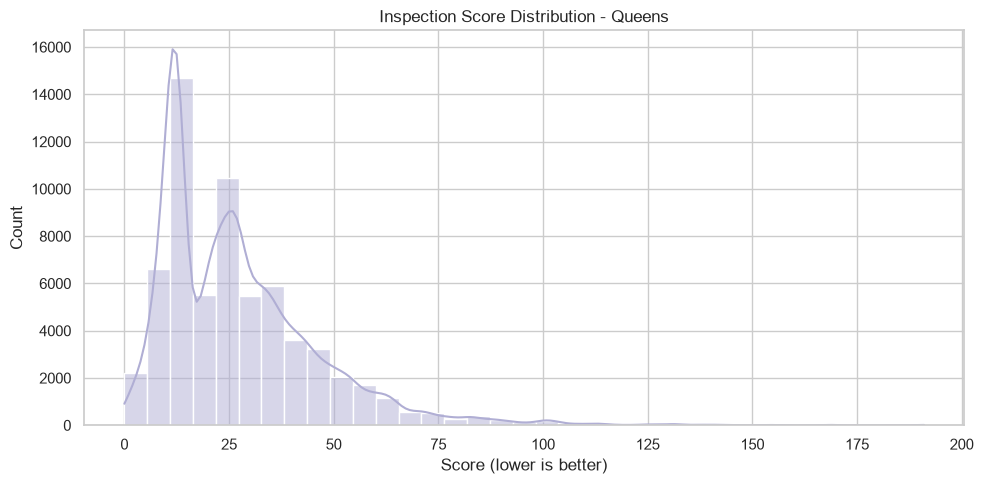

In [13]:
# Inspection Score Distribution - Queens
plt.figure(figsize=(10, 5))
sns.histplot(inspections_df['score'].dropna(), bins=35, color=inspection_colors[0], kde=True)
plt.title('Inspection Score Distribution - Queens')
plt.xlabel('Score (lower is better)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_17736\4091679148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette=inspection_colors)


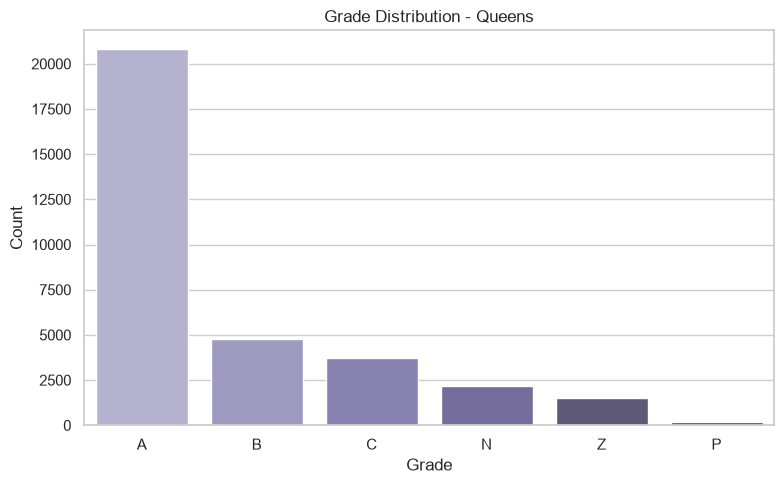

In [14]:
# Grade Distribution - Queens
grade_counts = inspections_df['grade'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette=inspection_colors)
plt.title('Grade Distribution - Queens')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

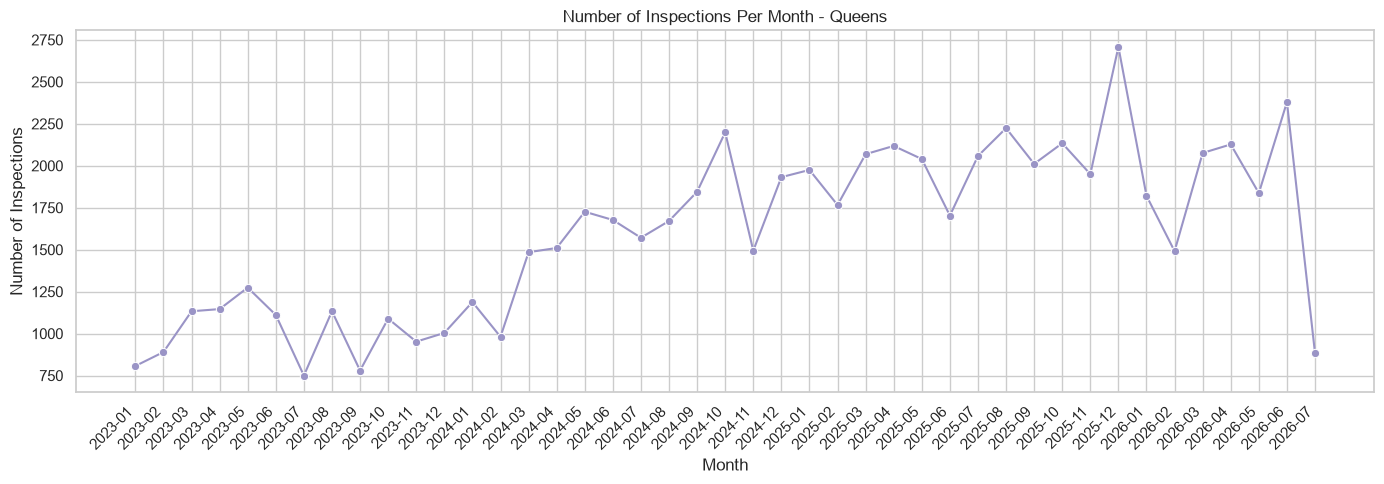

In [15]:
# Number of Inspections Per Year - Queens
inspections_df['month'] = pd.to_datetime(inspections_df['inspection_date']).dt.to_period('M')
month_counts = inspections_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=month_counts.index.astype(str), y=month_counts.values, marker='o', color=inspection_colors[1])
plt.title('Number of Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_17736\1986180202.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")


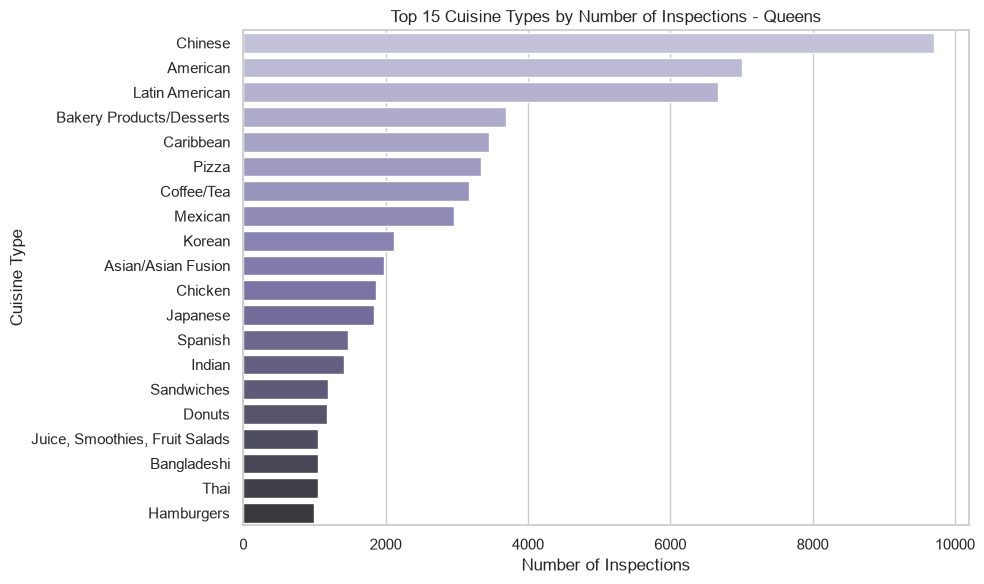

In [16]:
# Top 20 Cuisine Types by Number of Inspections - Queens
top_cuisines = inspections_df['cuisine_description'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")
plt.title('Top 15 Cuisine Types by Number of Inspections - Queens')
plt.xlabel('Number of Inspections')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()

---

## Rodent Inspection Data Analysis (Cleaning, Exploration, Visualization)

In [17]:
rodents_df.shape

(49781, 7)

In [18]:
rodents_df.columns

Index(['inspection_type', 'zip_code', 'borough', 'inspection_date', 'result',
       'latitude', 'longitude'],
      dtype='str')

In [19]:
rodents_df.head()

,inspection_type,zip_code,borough,inspection_date,result,latitude,longitude
0,Treatments,11433.0,Queens,2026-04-21T11:40:36.000,Bait applied,40.705653,-73.792109
1,Initial,11691.0,Queens,2026-02-27T10:30:57.000,Passed,40.606437,-73.752314
2,Initial,11434.0,Queens,2026-01-15T13:16:31.000,Passed,40.663249,-73.769217
3,Compliance,11434.0,Queens,2026-01-15T10:56:21.000,Passed,40.666955,-73.771003
4,Initial,11414.0,Queens,2023-05-24T15:00:04.000,Passed,40.654139,-73.830804


In [20]:
rodents_df.isna().sum()

inspection_type      0
zip_code           216
borough              0
inspection_date      0
result               0
latitude           187
longitude          187
dtype: int64

In [21]:
rodents_df['inspection_type'].value_counts()

inspection_type
Initial       27974
Compliance    11891
Treatments     9742
Clean Ups       130
Stoppage         44
Name: count, dtype: int64

In [22]:
rodents_df['result'].value_counts()

result
Passed                                      21490
Failed for Rat Activity                      9151
Bait applied                                 9006
Failed for Other Reason                      5306
Failed for Rat Activity and Other Reason     3918
Monitoring visit                              736
Cleanup done                                  130
Stoppage done                                  44
Name: count, dtype: int64

### Key Metrics:

C:\Users\chena\AppData\Local\Temp\ipykernel_17736\2695707273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)
C:\Users\chena\AppData\Local\Temp\ipykernel_17736\2695707273.py:4: UserWarning: 
The palette list has fewer values (6) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)


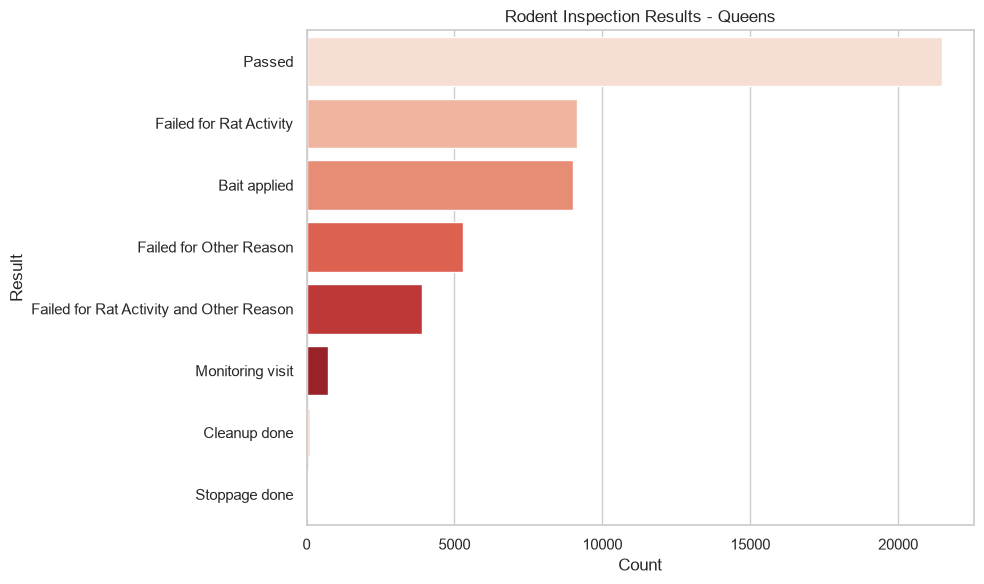

In [23]:
result_counts = rodents_df['result'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)
plt.title('Rodent Inspection Results - Queens')
plt.xlabel('Count')
plt.ylabel('Result')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_17736\3472836620.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)
C:\Users\chena\AppData\Local\Temp\ipykernel_17736\3472836620.py:4: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)


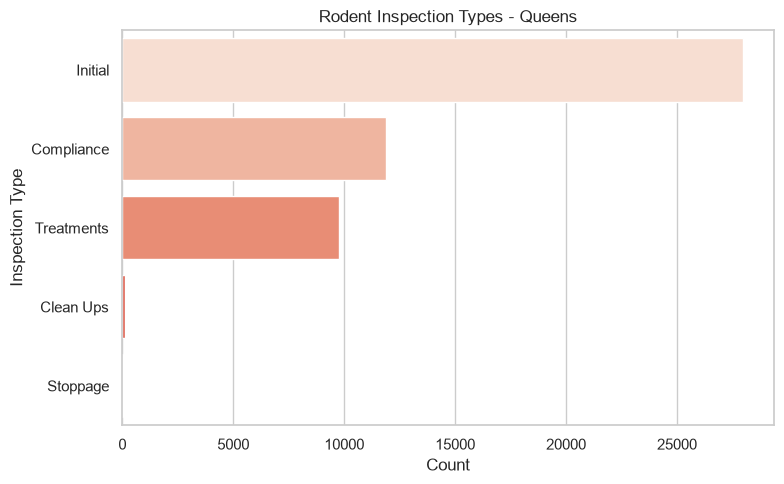

In [24]:
type_counts = rodents_df['inspection_type'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)
plt.title('Rodent Inspection Types - Queens')
plt.xlabel('Count')
plt.ylabel('Inspection Type')
plt.tight_layout()
plt.show()

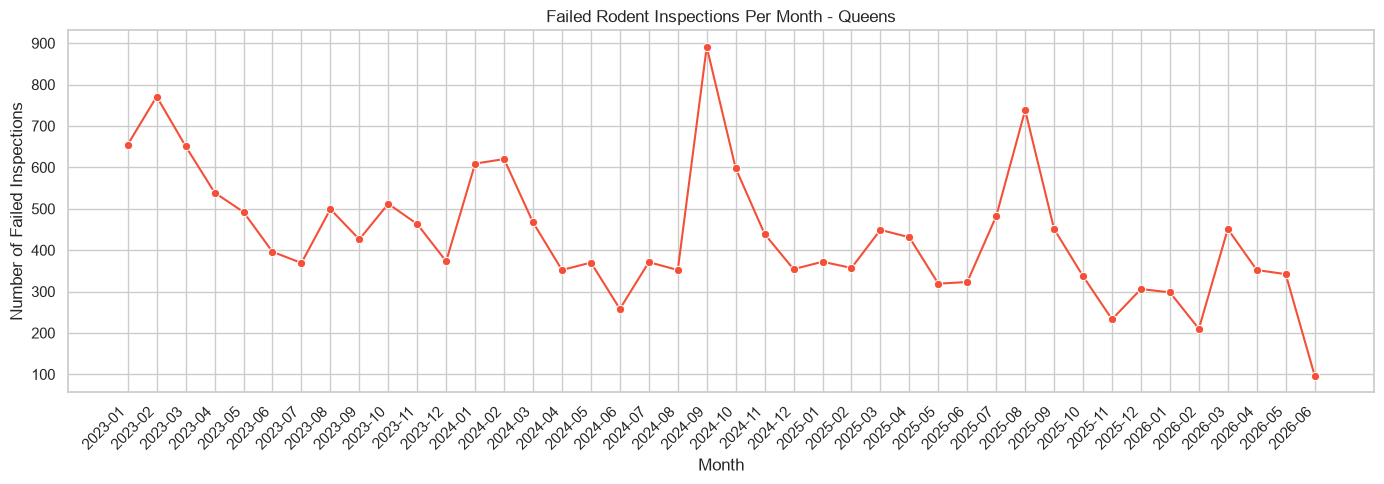

In [25]:
rodents_df['month'] = pd.to_datetime(rodents_df['inspection_date']).dt.to_period('M')

failed_df = rodents_df[rodents_df['result'].str.contains('Failed', na=False)]
failed_monthly = failed_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=failed_monthly.index.astype(str), y=failed_monthly.values, marker='o', color=rodent_colors[3])
plt.title('Failed Rodent Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Failed Inspections')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

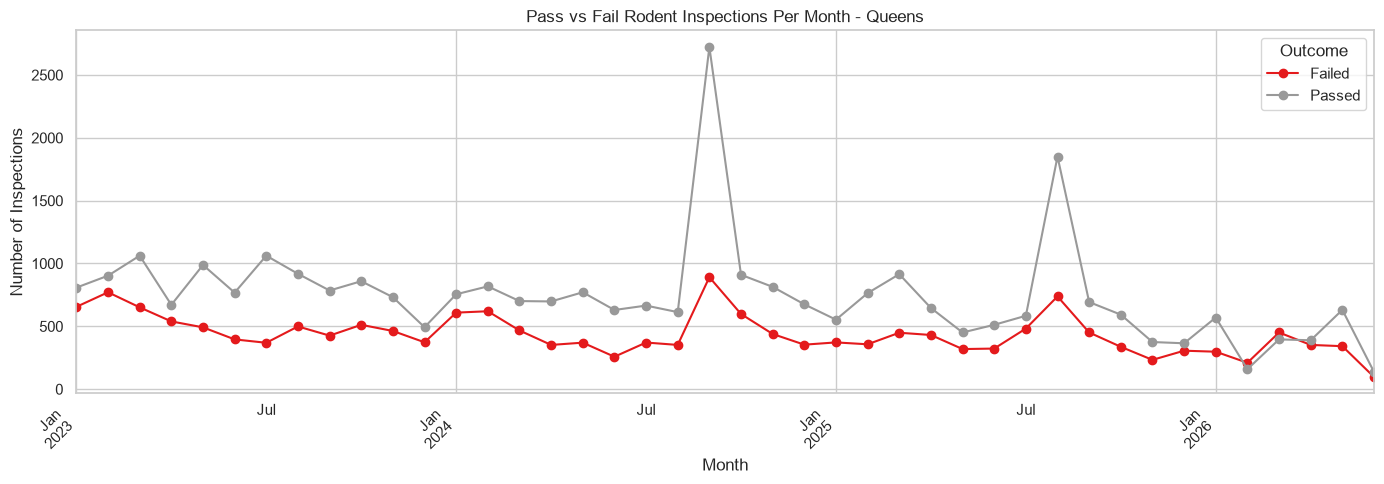

In [26]:
rodents_df['outcome'] = rodents_df['result'].apply(
    lambda x: 'Failed' if 'Failed' in str(x) else 'Passed'
)

outcome_monthly = rodents_df.groupby(['month', 'outcome']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
outcome_monthly.plot(kind='line', marker='o', colormap='Set1', ax=plt.gca())
plt.title('Pass vs Fail Rodent Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Outcome')
plt.tight_layout()

plt.show()

---

## 311 Complaints Data Analysis (Cleaning, Exploration, Visualization)

In [27]:
complaints_df.shape

(3000000, 8)

In [28]:
complaints_df.columns

Index(['created_date', 'agency', 'complaint_type', 'descriptor',
       'incident_zip', 'borough', 'latitude', 'longitude'],
      dtype='str')

In [29]:
complaints_df.head()

,created_date,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude
0,2026-07-15T02:37:54.000,DOT,Street Condition,Pothole,11420.0,QUEENS,NaN,NaN
1,2026-07-15T02:37:04.000,DOT,Street Condition,Pothole,11434.0,QUEENS,NaN,NaN
2,2026-07-15T02:35:37.000,DOT,Street Condition,Pothole,11434.0,QUEENS,NaN,NaN
3,2026-07-15T02:34:44.000,DOT,Street Condition,Pothole,11434.0,QUEENS,NaN,NaN
4,2026-07-15T02:33:50.000,DOT,Street Condition,Pothole,11434.0,QUEENS,NaN,NaN


In [30]:
complaints_df.isna().sum()

created_date          0
agency                0
complaint_type        0
descriptor        44732
incident_zip      31626
borough               0
latitude          76011
longitude         76011
dtype: int64

In [31]:
complaints_df['agency'].value_counts()

agency
NYPD          1535010
HPD            342803
DSNY           295604
DOT            251419
DEP            180674
DPR            147084
DOB             95462
DOHMH           60827
EDC             27108
TLC             26102
DHS             19043
DCWP            16407
DOE              1475
OOS               756
OTI               121
NYC311-PRD        104
3-1-1               1
Name: count, dtype: int64

In [32]:
complaints_df['complaint_type'].value_counts().head(20)

complaint_type
Illegal Parking             574492
Blocked Driveway            258413
Noise - Residential         257047
HEAT/HOT WATER              134557
Street Condition            108407
Abandoned Vehicle           100965
Noise - Street/Sidewalk      92204
Water System                 65289
UNSANITARY CONDITION         58799
Drug Activity                58194
Derelict Vehicles            54706
Noise - Commercial           48004
Noise - Vehicle              47271
Dirty Condition              47074
Traffic Signal Condition     46597
Missed Collection            45705
Damaged Tree                 44541
Sewer                        40860
Illegal Dumping              38379
Noise                        37583
Name: count, dtype: int64

In [33]:
complaints_df['descriptor'].value_counts()

descriptor
Loud Music/Party                 271107
No Access                        185358
Blocked Hydrant                  179966
Posted Parking Sign Violation    114356
With License Plate               100965
                                  ...  
Dirt, Litter, Debris - Garage         1
Supervisory                           1
User Unlicensed                       1
Debris                                1
Ticket Broker                         1
Name: count, Length: 1034, dtype: int64

### Key Metrics

C:\Users\chena\AppData\Local\Temp\ipykernel_17736\4250082746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_complaints.values, y=top_complaints.index, palette="Oranges_d")


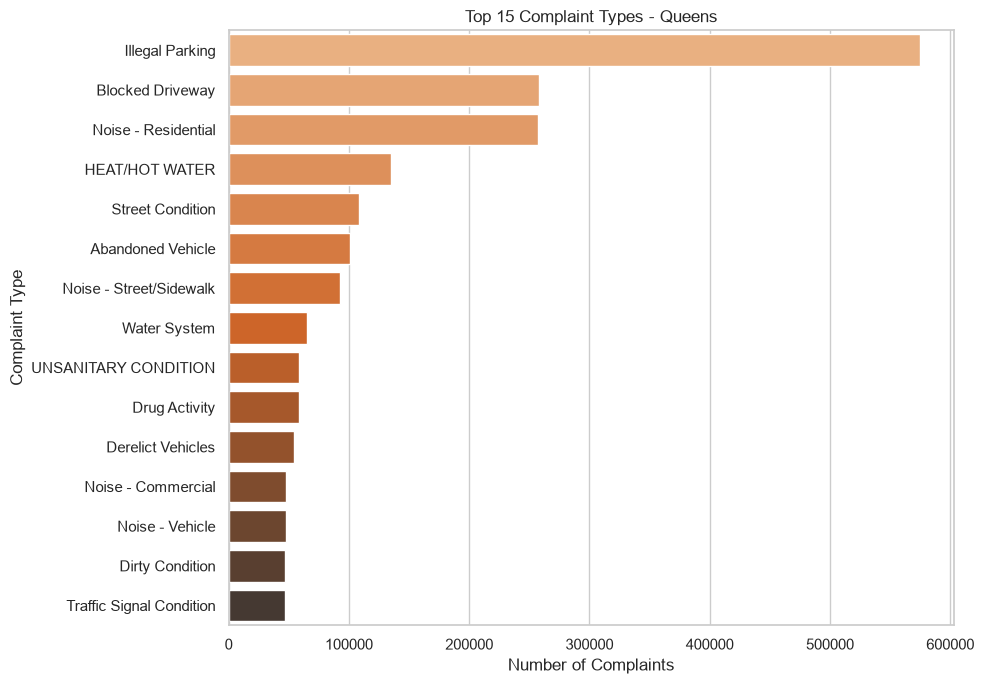

In [34]:
top_complaints = complaints_df['complaint_type'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_complaints.values, y=top_complaints.index, palette="Oranges_d")
plt.title('Top 15 Complaint Types - Queens')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_17736\939093494.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agency_counts.values, y=agency_counts.index, palette="Oranges_d")


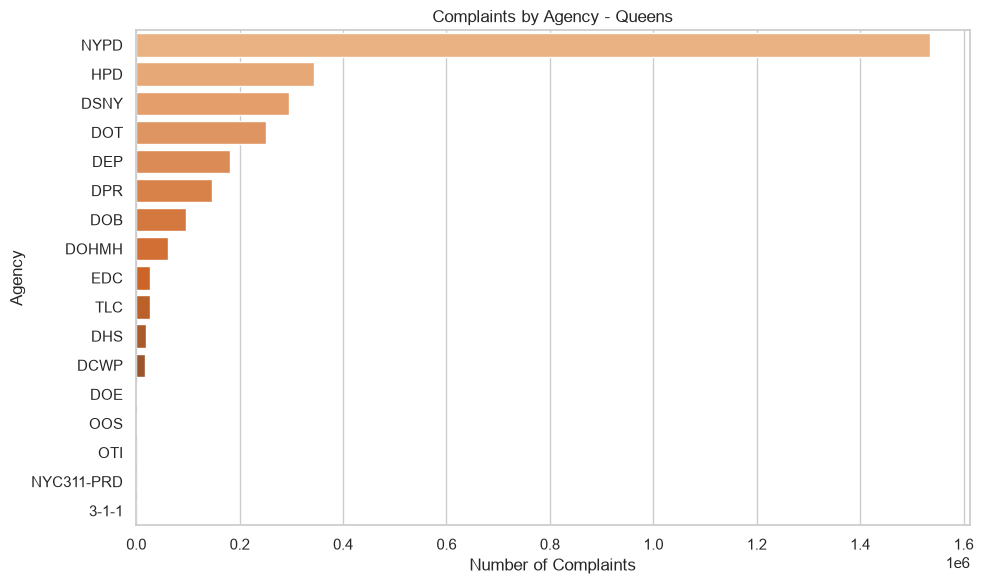

In [35]:
agency_counts = complaints_df['agency'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=agency_counts.values, y=agency_counts.index, palette="Oranges_d")
plt.title('Complaints by Agency - Queens')
plt.xlabel('Number of Complaints')
plt.ylabel('Agency')
plt.tight_layout()
plt.show()

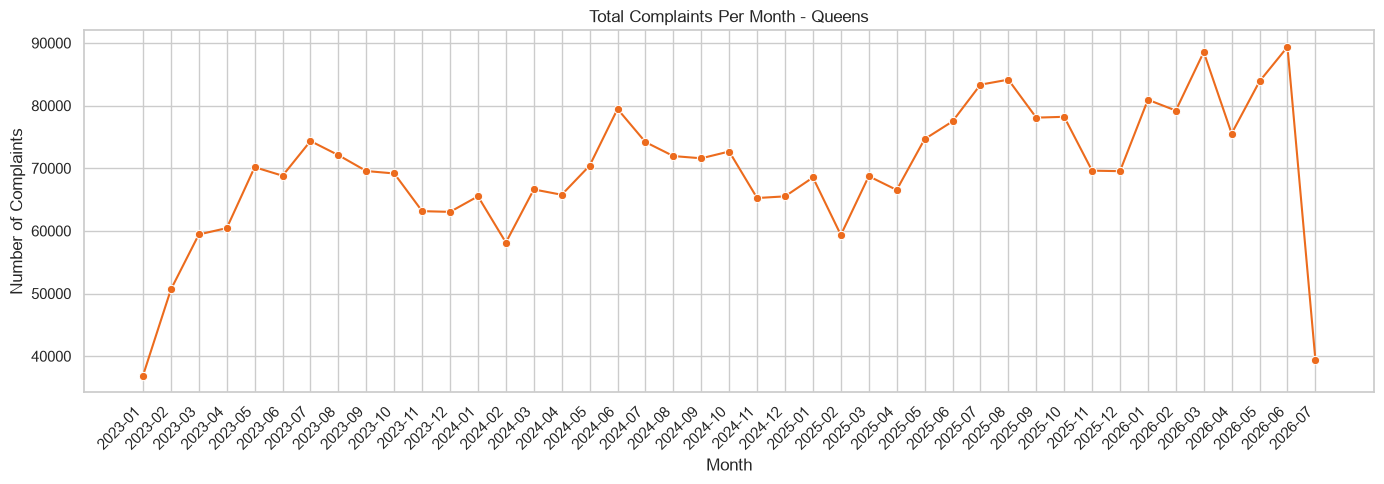

In [36]:
complaints_df['month'] = pd.to_datetime(complaints_df['created_date']).dt.to_period('M')
monthly_complaints = complaints_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=monthly_complaints.index.astype(str), y=monthly_complaints.values, marker='o', color=complaints_colors[2])
plt.title('Total Complaints Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

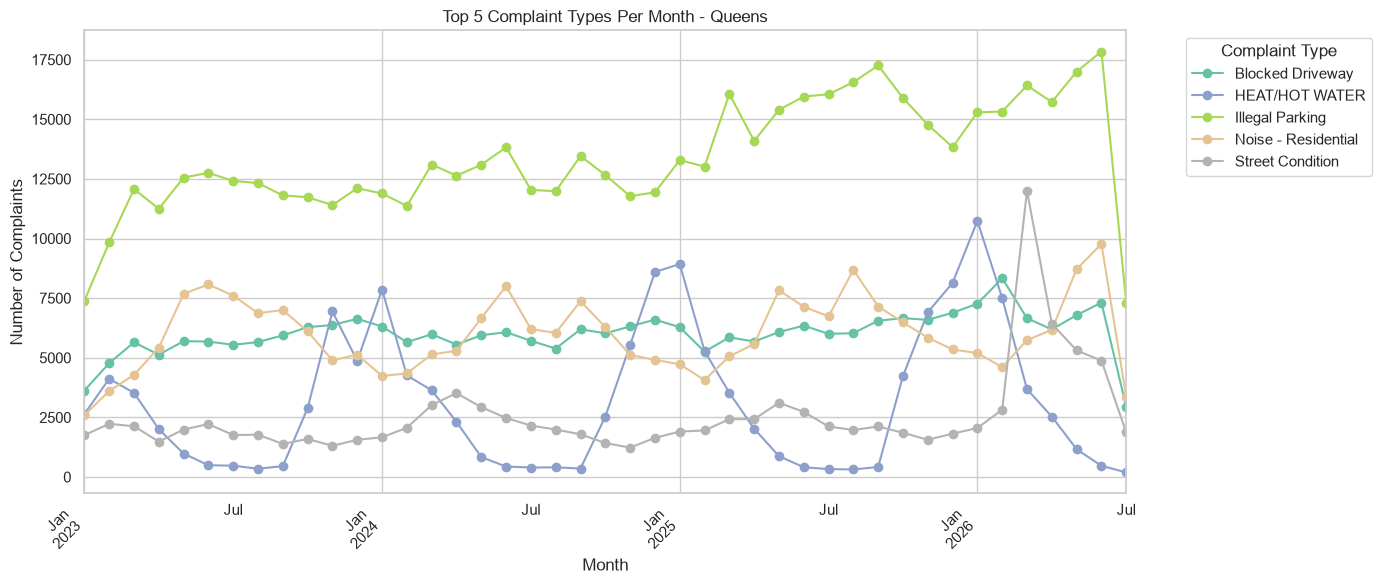

In [37]:
top5 = complaints_df['complaint_type'].value_counts().head(5).index

top5_monthly = (
    complaints_df[complaints_df['complaint_type'].isin(top5)]
    .groupby(['month', 'complaint_type'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 6))
top5_monthly.plot(kind='line', marker='o', colormap='Set2', ax=plt.gca())
plt.title('Top 5 Complaint Types Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Complaint Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---